In [ ]:
#Import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn


In [ ]:
#Load data
df=pd.read_csv('/content/drive/MyDrive/Alvi/Online Sales Data.csv')
df.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [ ]:
#Cleaning dataset
df['Date']=pd.to_datetime(df['Date'])
print(df.isnull().sum())
print(df.duplicated().sum())

print(df.describe())
df['validate']=df['Units Sold']*df['Unit Price']
df.head()

Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64
0
       Transaction ID                 Date  Units Sold   Unit Price  \
count       240.00000                  240  240.000000   240.000000   
mean      10120.50000  2024-04-29 12:00:00    2.158333   236.395583   
min       10001.00000  2024-01-01 00:00:00    1.000000     6.500000   
25%       10060.75000  2024-02-29 18:00:00    1.000000    29.500000   
50%       10120.50000  2024-04-29 12:00:00    2.000000    89.990000   
75%       10180.25000  2024-06-28 06:00:00    3.000000   249.990000   
max       10240.00000  2024-08-27 00:00:00   10.000000  3899.990000   
std          69.42622                  NaN    1.322454   429.446695   

       Total Revenue  
count     240.000000  
mean      335.699375  
min         6.500000  
25%        62.965000  
50%       179.970000  
75%      

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method,validate
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card,1999.98
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal,499.99
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card,209.97
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card,63.96
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal,89.99


In [ ]:
#Revenue Check
#Extract time features
df['Month'] = df['Date'].dt.month


monthly = df.groupby('Month')['Total Revenue'].sum().reset_index()
print(monthly)
region_rev=df.groupby('Region')['Total Revenue'].sum().sort_values(ascending=False).reset_index()
print(region_rev)
cata_rev=df.groupby('Product Category')['Total Revenue'].sum().sort_values(ascending=False).reset_index()
print(cata_rev)



   Month  Total Revenue
0      1       14548.32
1      2       10803.37
2      3       12849.24
3      4       12451.69
4      5        8455.49
5      6        7384.55
6      7        6797.08
7      8        7278.11
          Region  Total Revenue
0  North America       36844.34
1           Asia       22455.45
2         Europe       21268.06
  Product Category  Total Revenue
0      Electronics       34982.41
1  Home Appliances       18646.16
2           Sports       14326.52
3         Clothing        8128.93
4  Beauty Products        2621.90
5            Books        1861.93


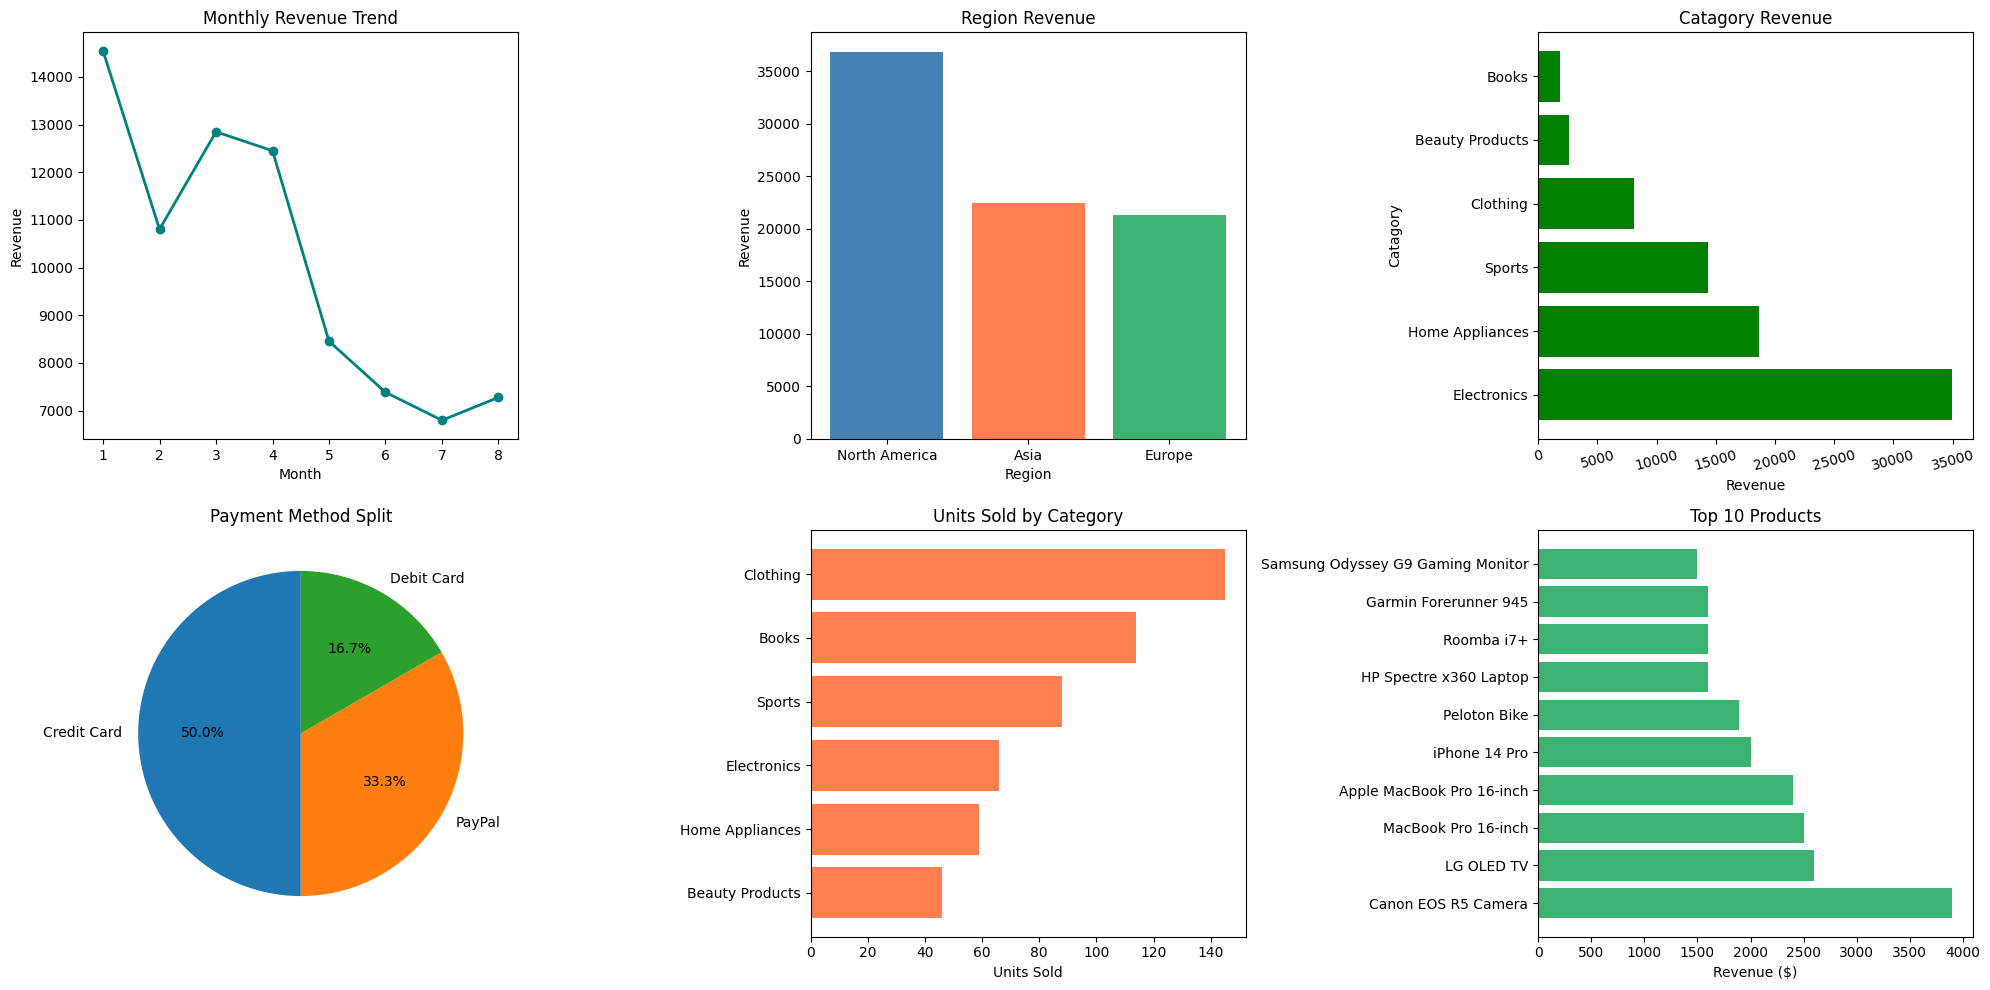

In [ ]:
#Visualize
fig, axes=plt.subplots(2,3,figsize=(20,10))
#Monthly revenue
axes[0,0].plot(monthly['Month'], monthly['Total Revenue'], marker='o', color='teal', linewidth=2)
axes[0,0].set_title('Monthly Revenue Trend')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Revenue')

#Region revenue
axes[0,1].bar(region_rev['Region'], region_rev['Total Revenue'], color=['steelblue','coral','mediumseagreen'])
axes[0,1].set_title('Region Revenue')
axes[0,1].set_xlabel('Region')
axes[0,1].set_ylabel('Revenue')
axes[0,2].tick_params(axis='x', rotation=15)

#Catagory revenue
axes[0,2].barh(cata_rev['Product Category'], cata_rev['Total Revenue'], color='green')
axes[0,2].set_title('Catagory Revenue')
axes[0,2].set_xlabel('Revenue')
axes[0,2].set_ylabel('Catagory')

# 4. Payment Method Distribution
payment = df['Payment Method'].value_counts()
axes[1,0].pie(payment.values, labels=payment.index, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Payment Method Split')

# 5. Units Sold by Category
units = df.groupby('Product Category')['Units Sold'].sum().sort_values()
axes[1,1].barh(units.index, units.values, color='coral')
axes[1,1].set_title('Units Sold by Category')
axes[1,1].set_xlabel('Units Sold')

# 6. Top 10 Products by Revenue
top10 = df.groupby('Product Name')['Total Revenue'].sum().sort_values(ascending=False).head(10)
axes[1,2].barh(top10.index, top10.values, color='mediumseagreen')
axes[1,2].set_title('Top 10 Products')
axes[1,2].set_xlabel('Revenue ($)')

plt.tight_layout()
plt.show()

In [ ]:
# Step 5 — Deep dive numbers
print("BUSINESS SUMMARY \n")

total_rev = df['Total Revenue'].sum()
print(f"Total Revenue (Jan-Aug): ${total_rev:,.2f}")
print(f"Average Order Value: ${df['Total Revenue'].mean():,.2f}")
print(f"Best Month: Jan (${monthly['Total Revenue'].max():,.2f})")
print(f"Worst Month: Jul (${monthly['Total Revenue'].min():,.2f})")
print(f"Revenue Drop Jan→Jul: {((monthly['Total Revenue'].iloc[-2] - monthly['Total Revenue'].iloc[0]) / monthly['Total Revenue'].iloc[0] * 100):.1f}%")

print("\n CATEGORY INSIGHTS ")
cat_units = df.groupby('Product Category').agg(
    total_revenue=('Total Revenue','sum'),
    total_units=('Units Sold','sum'),
    avg_order=('Total Revenue','mean')
).sort_values('total_revenue', ascending=False)
cat_units['revenue_per_unit'] = (cat_units['total_revenue'] / cat_units['total_units']).round(2)
print(cat_units)

print("\n PAYMENT METHODS ")
print(df['Payment Method'].value_counts(normalize=True).mul(100).round(1))

BUSINESS SUMMARY 

Total Revenue (Jan-Aug): $80,567.85
Average Order Value: $335.70
Best Month: Jan ($14,548.32)
Worst Month: Jul ($6,797.08)
Revenue Drop Jan→Jul: -53.3%

 CATEGORY INSIGHTS 
                  total_revenue  total_units  avg_order  revenue_per_unit
Product Category                                                         
Electronics            34982.41           66  874.56025            530.04
Home Appliances        18646.16           59  466.15400            316.04
Sports                 14326.52           88  358.16300            162.80
Clothing                8128.93          145  203.22325             56.06
Beauty Products         2621.90           46   65.54750             57.00
Books                   1861.93          114   46.54825             16.33

 PAYMENT METHODS 
Payment Method
Credit Card    50.0
PayPal         33.3
Debit Card     16.7
Name: proportion, dtype: float64


In [ ]:
print("""
=== BUSINESS RECOMMENDATIONS ===

1. REVENUE DECLINE [URGENT]
   Observation: Revenue dropped 53.3% from Jan to Jul
   So what: Droping overall revenue indicates business getting loss
   Action: Focus on more marketing, customer churn: are people coming back to buy the products? Or one time sell only? Have to focus on customer loyalty.

2. DOUBLE DOWN ON ELECTRONICS
   Observation: $530 revenue per unit vs $16 for Books
   So what: Selling electronics over books will increase revenue, as it sells well and gives more revenue than books
   Action: Reduce shelf storage for books and stock more electronics

3. CLOTHING STRATEGY
   Observation: Highest units sold (145) but low revenue per unit ($56)
   So what: Cloths sell more but generates low revenue per unit.
   Action: Bundle clothing items to increase order value

4. PAYMENT METHOD
   Observation: 50% Credit Card, only 16.7% Debit Card
   So what: More sales in credit card than debit card, revenue comes late.
   Action: Can introduce more payment methods(cash on delivery, UPI) to reduce checkout dropouts.

5. REGIONAL FOCUS
   Observation: North America = $36,844 vs Europe = $21,268
   So what: Customers from North America are spending more than Europe
   Action: Focus more products in North America
""")


=== BUSINESS RECOMMENDATIONS ===

1. REVENUE DECLINE [URGENT]
   Observation: Revenue dropped 53.3% from Jan to Jul
   So what: Droping overall revenue indicates business getting loss
   Action: Focus on more marketing, customer churn: are people coming back to buy the products? Or one time sell only? Have to focus on customer loyalty.

2. DOUBLE DOWN ON ELECTRONICS
   Observation: $530 revenue per unit vs $16 for Books
   So what: Selling electronics over books will increase revenue, as it sells well and gives more revenue than books
   Action: Reduce shelf storage for books and stock more electronics

3. CLOTHING STRATEGY
   Observation: Highest units sold (145) but low revenue per unit ($56)
   So what: Cloths sell more but generates low revenue per unit.
   Action: Bundle clothing items to increase order value

4. PAYMENT METHOD
   Observation: 50% Credit Card, only 16.7% Debit Card
   So what: More sales in credit card than debit card, revenue comes late.
   Action: Can introduce